In this notebook we compute the radial profiles using the ring-ring filter for each of the full samples.

The aperture photometry catalogs used here were generated using a modified version of the iskay2 ap_photo script. Instead of the default disk-minus-ring filter, we use a ring-minus-ring filter, with the central 1' of each submap masked out. The rings are equal-area. Corrections are applied to the 90 GHz data to account for the larger beam size relative to 150 GHz.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import make_profile as mp
import json

In [2]:
def make_profile_df(vals, freq):
    radii, dT, dT_err = vals
    profile_df = pd.DataFrame()
    profile_df['radius'] = radii
    profile_df['dT'] = dT
    profile_df['dT_err'] = dT_err
    profile_df['dy'] = mp.y_from_T(dT, freq)
    profile_df['dy_err'] = np.abs(mp.y_from_T(dT_err, freq))
    return profile_df

# LRG ring-ring

In [87]:
catalog_90 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f090_map_mult_rr_radio.hdf', header=0)
catalog_150 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f150_map_mult_rr_radio.hdf', header=0)

In [88]:
with open('paramfiles/f090_lrg_L36.json', 'r') as f:
    params = json.load(f)

catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [89]:
cols = ['dT_1p60_arcmin', 'dT_2p10_arcmin',
       'dT_2p60_arcmin', 'dT_3p10_arcmin', 'dT_3p60_arcmin', 'dT_4p10_arcmin',
       'dT_4p60_arcmin', 'dT_5p10_arcmin', 'dT_5p60_arcmin', 'dT_6p10_arcmin',
       'dT_6p60_arcmin']
radii = np.arange(1.6, 7.1, 0.5)

In [90]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [91]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)

In [92]:
params['min_r'], params['max_r'] # radius range of beamcorr

(0.6, 7.1)

<ErrorbarContainer object of 3 artists>

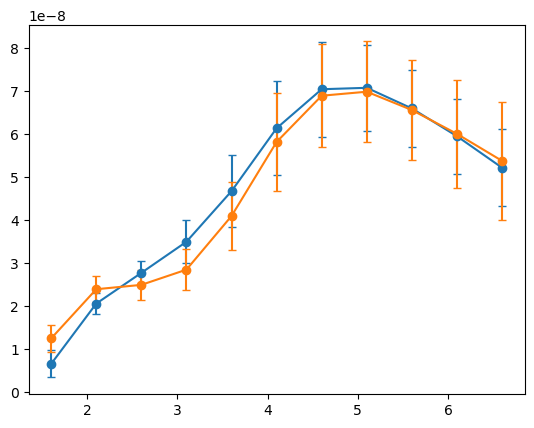

In [93]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values/params['beam_corr'][1:-1], yerr=df_90['dy_err'].values/params['beam_corr'][1:-1], capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

In [94]:
df_90['dy_bc'] = df_90['dy'].values/params['beam_corr'][1:-1]
df_90['dy_err_bc'] = df_90['dy_err'].values/params['beam_corr'][1:-1]
df_150['dy_bc'] = df_150['dy'].values
df_150['dy_err_bc'] = df_150['dy_err'].values

In [95]:
df_90.to_csv('profiles/f090_lrg_L36_rr_profiles.csv')
df_150.to_csv('profiles/f150_lrg_L36_rr_profiles.csv')

# BGS ring-ring

In [96]:
catalog_90 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f090_map_mult_rr_radio.hdf', header=0)
catalog_150 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f150_map_mult_rr_radio.hdf', header=0)

In [97]:
with open('paramfiles/f090_bgs_M10.json', 'r') as f:
    params = json.load(f)
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [98]:
cols = ['dT_1p20_arcmin', 'dT_1p70_arcmin', 'dT_2p20_arcmin', 'dT_2p70_arcmin',
       'dT_3p20_arcmin', 'dT_3p70_arcmin', 'dT_4p20_arcmin', 'dT_4p70_arcmin',
       'dT_5p20_arcmin', 'dT_5p70_arcmin', 'dT_6p20_arcmin', 'dT_6p70_arcmin']
radii = np.arange(1.2, 7.2, 0.5)

In [99]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [100]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)

In [101]:
params['min_r'], params['max_r'] # radius range of beamcorr

(0.7, 7.2)

<ErrorbarContainer object of 3 artists>

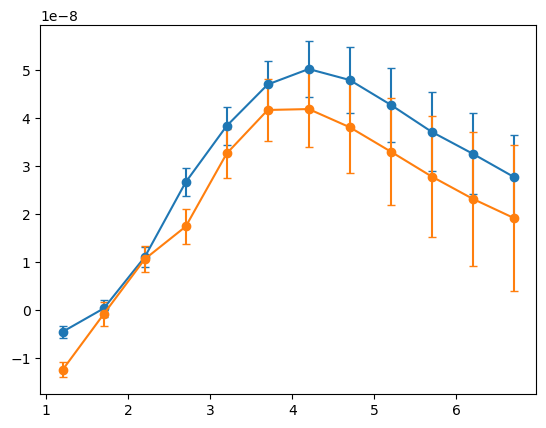

In [102]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values/params['beam_corr'][1:], yerr=df_90['dy_err'].values/params['beam_corr'][1:], capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

In [103]:
df_90['dy_bc'] = df_90['dy'].values/params['beam_corr'][1:]
df_90['dy_err_bc'] = df_90['dy_err'].values/params['beam_corr'][1:]
df_150['dy_bc'] = df_150['dy'].values
df_150['dy_err_bc'] = df_150['dy_err'].values

In [104]:
df_90.to_csv('profiles/f090_bgs_M10_rr_profiles.csv')
df_150.to_csv('profiles/f150_bgs_M10_rr_profiles.csv')

# Optical ring-ring

In [105]:
catalog_90 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f090_map_mult_rr_radio.hdf', header=0)
catalog_150 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f150_map_mult_rr_radio.hdf', header=0)

In [106]:
with open('paramfiles/f090_opt_L5.json', 'r') as f:
    params = json.load(f)

In [107]:
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [108]:
cols = ['dT_1p40_arcmin', 'dT_1p90_arcmin', 'dT_2p40_arcmin', 'dT_2p90_arcmin',
       'dT_3p40_arcmin', 'dT_3p90_arcmin', 'dT_4p40_arcmin', 'dT_4p90_arcmin',
       'dT_5p40_arcmin', 'dT_5p90_arcmin', 'dT_6p40_arcmin', 'dT_6p90_arcmin']
radii = np.arange(1.4, 7.4, 0.5)

In [109]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [110]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)

In [111]:
params['min_r'], params['max_r'] # radius range of beamcorr

(0.9, 7.4)

<ErrorbarContainer object of 3 artists>

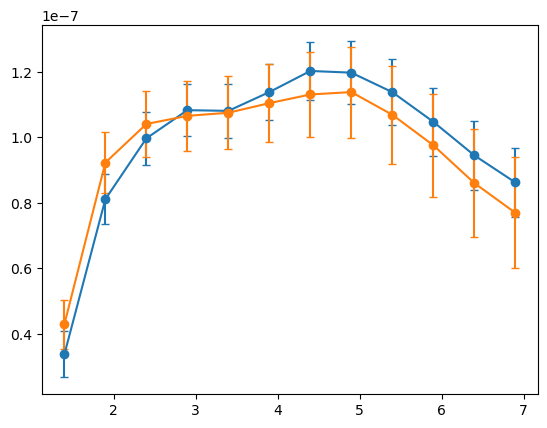

In [112]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values/params['beam_corr'][1:], yerr=df_90['dy_err'].values/params['beam_corr'][1:], capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

In [113]:
df_90['dy_bc'] = df_90['dy'].values/params['beam_corr'][1:]
df_90['dy_err_bc'] = df_90['dy_err'].values/params['beam_corr'][1:]
df_150['dy_bc'] = df_150['dy'].values
df_150['dy_err_bc'] = df_150['dy_err'].values

In [114]:
df_90.to_csv('profiles/f090_opt_L5_rr_profiles.csv')
df_150.to_csv('profiles/f150_opt_L5_rr_profiles.csv')

# Now look at radio-clean samples

## LRG

In [3]:
catalog_90 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f090_map_mult_rr_radio.hdf', header=0)
catalog_150 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f150_map_mult_rr_radio.hdf', header=0)

In [4]:
with open('paramfiles/f090_lrg_L36_radio_clean.json', 'r') as f:
    params = json.load(f)

catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [5]:
cols = ['dT_1p60_arcmin', 'dT_2p10_arcmin',
       'dT_2p60_arcmin', 'dT_3p10_arcmin', 'dT_3p60_arcmin', 'dT_4p10_arcmin',
       'dT_4p60_arcmin', 'dT_5p10_arcmin', 'dT_5p60_arcmin', 'dT_6p10_arcmin',
       'dT_6p60_arcmin']
radii = np.arange(1.6, 7.1, 0.5)
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)

<ErrorbarContainer object of 3 artists>

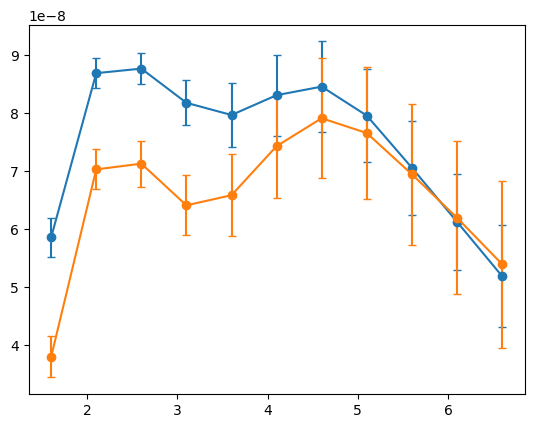

In [6]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values/params['beam_corr'][1:-1], yerr=df_90['dy_err'].values/params['beam_corr'][1:-1], capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

In [9]:
df_90['dy_bc'] = df_90['dy'].values/params['beam_corr'][1:-1]
df_90['dy_err_bc'] = df_90['dy_err'].values/params['beam_corr'][1:-1]
df_150['dy_bc'] = df_150['dy'].values
df_150['dy_err_bc'] = df_150['dy_err'].values
df_90.to_csv('profiles/f090_lrg_L36_radio_clean_rr_profiles.csv')
df_150.to_csv('profiles/f150_lrg_L36_radio_clean_rr_profiles.csv')

## BGS

In [10]:
catalog_90 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f090_map_mult_rr_radio.hdf', header=0)
catalog_150 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f150_map_mult_rr_radio.hdf', header=0)

In [15]:
with open('paramfiles/f090_bgs_M10_radio_clean.json', 'r') as f:
    params = json.load(f)
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [16]:
cols = ['dT_1p20_arcmin', 'dT_1p70_arcmin', 'dT_2p20_arcmin', 'dT_2p70_arcmin',
       'dT_3p20_arcmin', 'dT_3p70_arcmin', 'dT_4p20_arcmin', 'dT_4p70_arcmin',
       'dT_5p20_arcmin', 'dT_5p70_arcmin', 'dT_6p20_arcmin', 'dT_6p70_arcmin']
radii = np.arange(1.2, 7.2, 0.5)
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)

<ErrorbarContainer object of 3 artists>

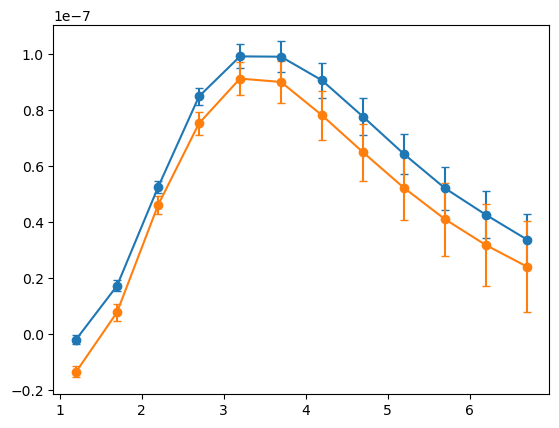

In [17]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values/params['beam_corr'][1:], yerr=df_90['dy_err'].values/params['beam_corr'][1:], capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

In [18]:
df_90['dy_bc'] = df_90['dy'].values/params['beam_corr'][1:]
df_90['dy_err_bc'] = df_90['dy_err'].values/params['beam_corr'][1:]
df_150['dy_bc'] = df_150['dy'].values
df_150['dy_err_bc'] = df_150['dy_err'].values
df_90.to_csv('profiles/f090_bgs_M10_radio_clean_rr_profiles.csv')
df_150.to_csv('profiles/f150_bgs_M10_radio_clean_rr_profiles.csv')

## Optical

In [19]:
catalog_90 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f090_map_mult_rr_radio.hdf', header=0)
catalog_150 = pd.read_hdf('/hpc/group/cosmology/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f150_map_mult_rr_radio.hdf', header=0)

In [20]:
with open('paramfiles/f090_opt_L5_radio_clean.json', 'r') as f:
    params = json.load(f)
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [21]:
cols = ['dT_1p40_arcmin', 'dT_1p90_arcmin', 'dT_2p40_arcmin', 'dT_2p90_arcmin',
       'dT_3p40_arcmin', 'dT_3p90_arcmin', 'dT_4p40_arcmin', 'dT_4p90_arcmin',
       'dT_5p40_arcmin', 'dT_5p90_arcmin', 'dT_6p40_arcmin', 'dT_6p90_arcmin']
radii = np.arange(1.4, 7.4, 0.5)
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)

<ErrorbarContainer object of 3 artists>

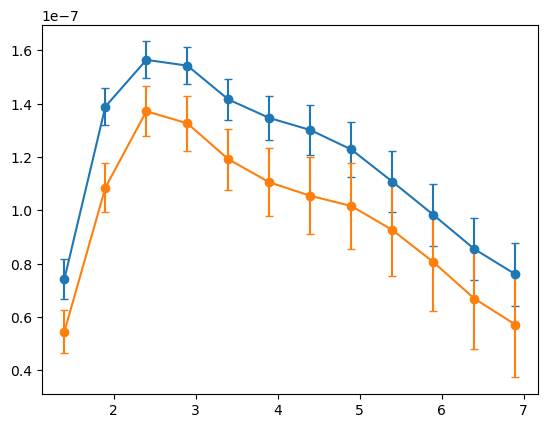

In [22]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values/params['beam_corr'][1:], yerr=df_90['dy_err'].values/params['beam_corr'][1:], capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

In [23]:
df_90['dy_bc'] = df_90['dy'].values/params['beam_corr'][1:]
df_90['dy_err_bc'] = df_90['dy_err'].values/params['beam_corr'][1:]
df_150['dy_bc'] = df_150['dy'].values
df_150['dy_err_bc'] = df_150['dy_err'].values
df_90.to_csv('profiles/f090_opt_L5_radio_clean_rr_profiles.csv')
df_150.to_csv('profiles/f150_opt_L5_radio_clean_rr_profiles.csv')

# Using srcfree maps

## LRG

In [15]:
catalog_90 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged_act-planck_dr6.02_coadd_AA_night_f090_map_srcfree.hdf', header=0)
catalog_150 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged_act-planck_dr6.02_coadd_AA_night_f150_map_srcfree.hdf', header=0)


In [16]:
with open('paramfiles/f090_srcfree_lrg_L36.json', 'r') as f:
    params = json.load(f)

catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [17]:
cols = ['dT_1p60_arcmin', 'dT_2p10_arcmin',
       'dT_2p60_arcmin', 'dT_3p10_arcmin', 'dT_3p60_arcmin', 'dT_4p10_arcmin',
       'dT_4p60_arcmin', 'dT_5p10_arcmin', 'dT_5p60_arcmin', 'dT_6p10_arcmin',
       'dT_6p60_arcmin']
radii = np.arange(1.6, 7.1, 0.5)

In [18]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [19]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)
df_90.to_csv('profiles/f090_srcfree_lrg_L36_rr_profiles.csv')
df_150.to_csv('profiles/f150_srcfree_lrg_L36_rr_profiles.csv')

<ErrorbarContainer object of 3 artists>

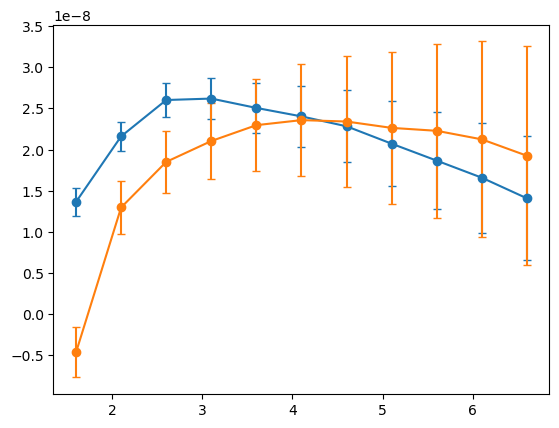

In [8]:
# not beam corrected
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values, yerr=df_90['dy_err'].values, capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

# BGS

In [28]:
catalog_90 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged_act-planck_dr6.02_coadd_AA_night_f090_map_srcfree.hdf', header=0)
catalog_150 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged_act-planck_dr6.02_coadd_AA_night_f150_map_srcfree.hdf', header=0)

In [29]:
with open('paramfiles/f090_srcfree_bgs_M10.json', 'r') as f:
    params = json.load(f)
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [30]:
cols = ['dT_1p20_arcmin', 'dT_1p70_arcmin', 'dT_2p20_arcmin', 'dT_2p70_arcmin',
       'dT_3p20_arcmin', 'dT_3p70_arcmin', 'dT_4p20_arcmin', 'dT_4p70_arcmin',
       'dT_5p20_arcmin', 'dT_5p70_arcmin', 'dT_6p20_arcmin', 'dT_6p70_arcmin']
radii = np.arange(1.2, 7.2, 0.5)

In [31]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [32]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)
df_90.to_csv('profiles/f090_srcfree_bgs_M10_rr_profiles.csv')
df_150.to_csv('profiles/f150_srcfree_bgs_M10_rr_profiles.csv')

<ErrorbarContainer object of 3 artists>

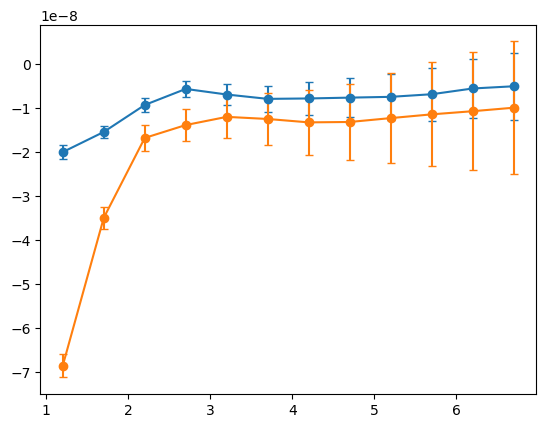

In [33]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values, yerr=df_90['dy_err'].values, capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

# Optical

In [20]:
catalog_90 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged_act-planck_dr6.02_coadd_AA_night_f090_map_srcfree.hdf', header=0)
catalog_150 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged_act-planck_dr6.02_coadd_AA_night_f150_map_srcfree.hdf', header=0)

In [21]:
with open('paramfiles/f090_srcfree_opt_L5.json', 'r') as f:
    params = json.load(f)

In [22]:
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [23]:
cols = ['dT_1p40_arcmin', 'dT_1p90_arcmin', 'dT_2p40_arcmin', 'dT_2p90_arcmin',
       'dT_3p40_arcmin', 'dT_3p90_arcmin', 'dT_4p40_arcmin', 'dT_4p90_arcmin',
       'dT_5p40_arcmin', 'dT_5p90_arcmin', 'dT_6p40_arcmin', 'dT_6p90_arcmin']
radii = np.arange(1.4, 7.4, 0.5)

In [24]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [25]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)
df_90.to_csv('profiles/f090_srcfree_opt_L5_rr_profiles.csv')
df_150.to_csv('profiles/f150_srcfree_opt_L5_rr_profiles.csv')

<ErrorbarContainer object of 3 artists>

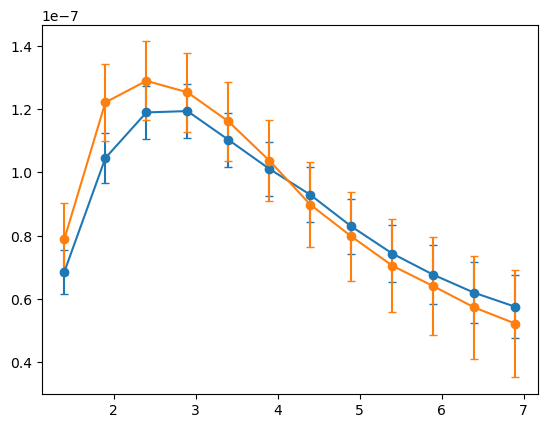

In [27]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values, yerr=df_90['dy_err'].values, capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

## LRG -- radio clean

In [34]:
catalog_90 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged_act-planck_dr6.02_coadd_AA_night_f090_map_srcfree.hdf', header=0)
catalog_150 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged_act-planck_dr6.02_coadd_AA_night_f150_map_srcfree.hdf', header=0)


In [35]:
with open('paramfiles/f090_srcfree_lrg_L36_radio_clean.json', 'r') as f:
    params = json.load(f)

catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [36]:
cols = ['dT_1p60_arcmin', 'dT_2p10_arcmin',
       'dT_2p60_arcmin', 'dT_3p10_arcmin', 'dT_3p60_arcmin', 'dT_4p10_arcmin',
       'dT_4p60_arcmin', 'dT_5p10_arcmin', 'dT_5p60_arcmin', 'dT_6p10_arcmin',
       'dT_6p60_arcmin']
radii = np.arange(1.6, 7.1, 0.5)

In [37]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [38]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)
df_90.to_csv('profiles/f090_srcfree_lrg_L36_radio_clean_rr_profiles.csv')
df_150.to_csv('profiles/f150_srcfree_lrg_L36_radio_clean_rr_profiles.csv')

<ErrorbarContainer object of 3 artists>

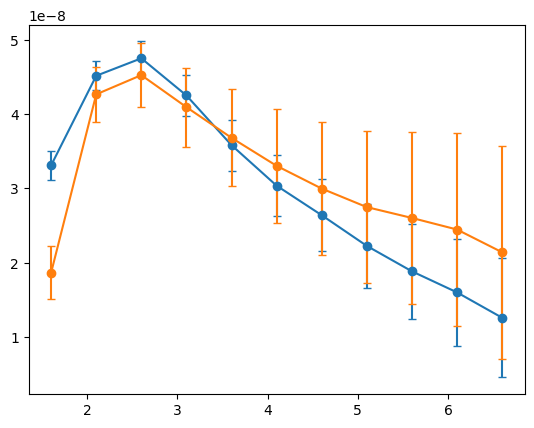

In [39]:
# not beam corrected
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values, yerr=df_90['dy_err'].values, capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

# BGS

In [40]:
catalog_90 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged_act-planck_dr6.02_coadd_AA_night_f090_map_srcfree.hdf', header=0)
catalog_150 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged_act-planck_dr6.02_coadd_AA_night_f150_map_srcfree.hdf', header=0)

In [41]:
with open('paramfiles/f090_srcfree_bgs_M10_radio_clean.json', 'r') as f:
    params = json.load(f)
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [42]:
cols = ['dT_1p20_arcmin', 'dT_1p70_arcmin', 'dT_2p20_arcmin', 'dT_2p70_arcmin',
       'dT_3p20_arcmin', 'dT_3p70_arcmin', 'dT_4p20_arcmin', 'dT_4p70_arcmin',
       'dT_5p20_arcmin', 'dT_5p70_arcmin', 'dT_6p20_arcmin', 'dT_6p70_arcmin']
radii = np.arange(1.2, 7.2, 0.5)

In [43]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [44]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)
df_90.to_csv('profiles/f090_srcfree_bgs_M10_radio_clean_rr_profiles.csv')
df_150.to_csv('profiles/f150_srcfree_bgs_M10_radio_clean_rr_profiles.csv')

<ErrorbarContainer object of 3 artists>

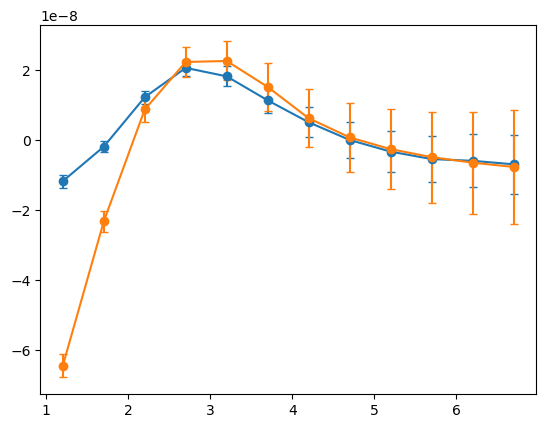

In [45]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values, yerr=df_90['dy_err'].values, capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')

# Optical

In [46]:
catalog_90 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged_act-planck_dr6.02_coadd_AA_night_f090_map_srcfree.hdf', header=0)
catalog_150 = pd.read_hdf('/work/jem189/scratch/data/ApPhotoResults/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged_act-planck_dr6.02_coadd_AA_night_f150_map_srcfree.hdf', header=0)

In [47]:
with open('paramfiles/f090_srcfree_opt_L5_radio_clean.json', 'r') as f:
    params = json.load(f)

In [48]:
catalog_queried_90 = catalog_90.query(params['query'])
catalog_queried_150 = catalog_150.query(params['query'])

In [49]:
cols = ['dT_1p40_arcmin', 'dT_1p90_arcmin', 'dT_2p40_arcmin', 'dT_2p90_arcmin',
       'dT_3p40_arcmin', 'dT_3p90_arcmin', 'dT_4p40_arcmin', 'dT_4p90_arcmin',
       'dT_5p40_arcmin', 'dT_5p90_arcmin', 'dT_6p40_arcmin', 'dT_6p90_arcmin']
radii = np.arange(1.4, 7.4, 0.5)

In [50]:
dT_90, dT_err_90 = mp.do_JK_mult(catalog_queried_90[cols].values, N=2000)
dT_150, dT_err_150 = mp.do_JK_mult(catalog_queried_150[cols].values, N=2000)

In [51]:
df_90 = make_profile_df([radii, dT_90, dT_err_90], 90e9)
df_150 = make_profile_df([radii, dT_150, dT_err_150], 150e9)
df_90.to_csv('profiles/f090_srcfree_opt_L5_radio_clean_rr_profiles.csv')
df_150.to_csv('profiles/f150_srcfree_opt_L5_radio_clean_rr_profiles.csv')

<ErrorbarContainer object of 3 artists>

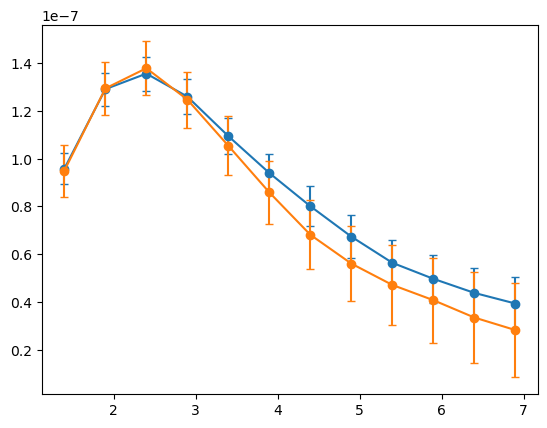

In [52]:
# note ring-ring profiles have fewer data points than the disk-ring profiles
plt.errorbar(df_90['radius'].values, df_90['dy'].values, yerr=df_90['dy_err'].values, capsize=3, marker='o')
plt.errorbar(df_150['radius'].values, df_150['dy'].values, yerr=df_150['dy_err'].values, capsize=3, marker='o')